# Programming in Python II - Final Coding Project

Author: Viktor Doychev

Student ID: k12441809

Save this file under a file name in the format k+matriculation_number.ipynb, e.g. *k1234567.ipynb*. Remember that for final submission all code cells must run without errors and all cells have to be evaluated.

The code cells are a basic scaffold - you can of course add new code cells if necessary. However, stick to the overall structure of the template to facilitate grading. Ensure to comment your code and structure it reasonably.

In [94]:
# This is just a minimum setup for reproducibility. Add more libraries as required.

import numpy as np
import torch
import matplotlib.pyplot as plt
import os
import pandas as pd

from sklearn.model_selection import train_test_split
import math

# Setting device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.backends.mps.is_available():
    device = torch.device("mps")

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

In [2]:
# checking successful setup
print(f"Using device: {device}")

Using device: cuda


In [3]:
# For visualization in Jupyter notebooks
%matplotlib inline

In [4]:
# Set working directory to the project folder
os.chdir("/home/exvick/Desktop/Python_II/challenge/satellite-image-classification")  # Change this to your project folder path
print(f"Current working directory: {os.getcwd()}")

Current working directory: /home/exvick/Desktop/Python_II/challenge/satellite-image-classification


In [5]:
# creating folder 'assets' if necessary
os.makedirs("assets", exist_ok=True)

#### Random seed for reproducing

In [36]:
random_state = 42

## Data Handling and Pre-Processing

In [50]:
# your code goes here (preprocess function)
def preprocess(data_folder: str) -> tuple[pd.DataFrame, dict]:

    label_dict = {
        'HerbaceousVegetation': 0,
        'AnnualCrop': 1,
        'Residential': 2,
        'Pasture': 3,
        'Industrial': 4,
        'River': 5,
        'Highway': 6,
        'Forest': 7,
        'PermanentCrop': 8,
        'SeaLake': 9
    }

    folders = []
    file_names = []

    for root, dirs, files in os.walk(data_folder):
        for n in files:
            # print(root, n, root.rsplit("/", 1)[-1])
            folders.append(str(root))
            file_names.append(str(n)) 

    df = pd.DataFrame({"folder":folders,"file_name":file_names})
    df["label_str"] = df["folder"].apply(lambda x: x.rsplit("/", 1)[-1])
    df["label"] = df["label_str"].map(label_dict)
    df.drop(columns="label_str", inplace=True)

    return df, label_dict

dataset,labels_map = preprocess("/home/exvick/Desktop/Python_II/challenge/satellite-image-classification/data")
dataset

,folder,file_name,label
0,/home/exvick/Desktop/Python_II/challenge/satel...,Residential_1131.jpg,2
1,/home/exvick/Desktop/Python_II/challenge/satel...,Residential_1662.jpg,2
2,/home/exvick/Desktop/Python_II/challenge/satel...,Residential_1120.jpg,2
3,/home/exvick/Desktop/Python_II/challenge/satel...,Residential_1815.jpg,2
4,/home/exvick/Desktop/Python_II/challenge/satel...,Residential_2768.jpg,2
...,...,...,...
9995,/home/exvick/Desktop/Python_II/challenge/satel...,River_575.jpg,5
9996,/home/exvick/Desktop/Python_II/challenge/satel...,River_1010.jpg,5
9997,/home/exvick/Desktop/Python_II/challenge/satel...,River_677.jpg,5
9998,/home/exvick/Desktop/Python_II/challenge/satel...,River_2380.jpg,5


In [35]:
# checking successful dataframe loading

# uncomment after preprocessing the dataset and adapt the variable name
print(f"Length of dataset: {len(dataset)}") # Should be 10000

Length of dataset: 10000


In [46]:
# your code goes here (splitting train/validation datasets)
X_train, X_val, y_train, y_val = train_test_split(
    dataset[["folder", "file_name"]], dataset["label"],
    test_size=0.2,
    random_state=random_state,
    stratify=dataset["label"]
)

## Exploratory Data Analysis (EDA)

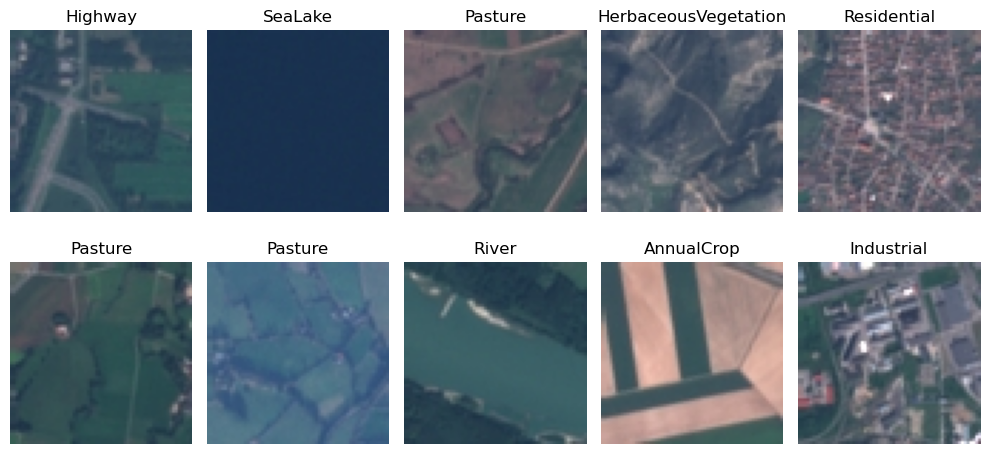

In [ ]:
# your code goes here (show_samples)
def show_samples(df: pd.DataFrame, num_samples: int = 5) -> None:

    ds_sample = df.sample(n=num_samples, random_state=3)  
    
    cols = min(num_samples, 5)
    rows = math.ceil(num_samples / cols)
    plt.figure(figsize=(10,5))
    for i in range(0, cols * rows):
        img = Image.open(str(ds_sample.iloc[i].folder+"/"+ds_sample.iloc[i].file_name))
        label = ds_sample.iloc[i].file_name.split("_")[0]
        plt.subplot(rows, cols, i+1)
        plt.title(label)
        plt.axis("off")
        plt.imshow(img)
                
    os.makedirs('assets/plots', exist_ok=True)
    plt.savefig('assets/plots/random_samples.png')

    plt.tight_layout()
    plt.show()

show_samples(dataset, 10)

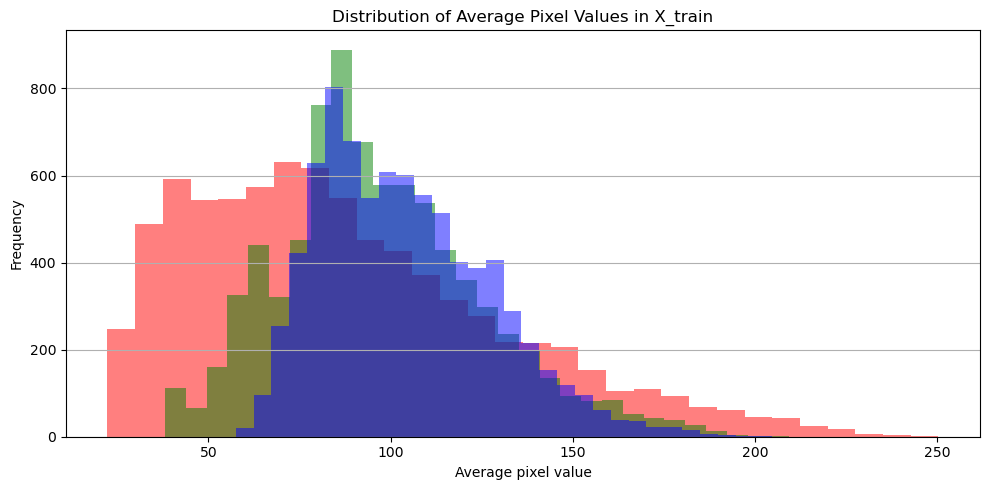

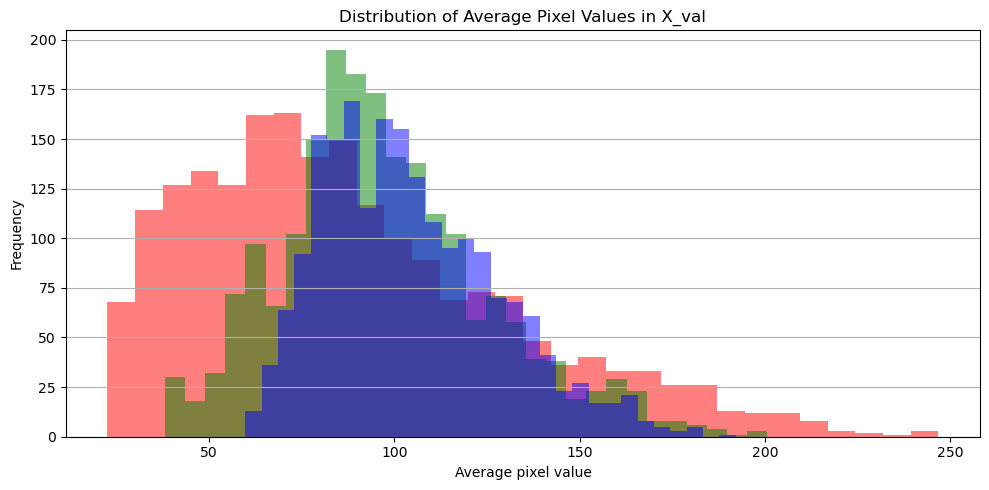

In [101]:
# your code goes here (average_pixel_plot)
def average_pixel_plot(df: pd.DataFrame, name: str) -> None:

    avg_r, avg_g, avg_b = [], [], []
    for i in range(len(df)):
        img = Image.open(str(df.iloc[i].folder+"/"+df.iloc[i].file_name))
        arr = np.array(img)
        # print(arr.shape)
        avg_r.append(arr[:,:,0].mean())
        avg_g.append(arr[:,:,1].mean())
        avg_b.append(arr[:,:,2].mean())

    plt.figure(figsize=(10,5))
    plt.hist(avg_r, bins=30, alpha=0.5, color="r")
    plt.hist(avg_g, bins=30, alpha=0.5, color="g")
    plt.hist(avg_b, bins=30, alpha=0.5, color="b")
    plt.title(f"Distribution of Average Pixel Values in {name}")
    plt.xlabel("Average pixel value")
    plt.ylabel("Frequency")
    plt.grid(axis="y")

    os.makedirs("assets/plots", exist_ok=True)
    plt.savefig(f"assets/plots/average_pixel_dictribution_{name}.png")

    plt.tight_layout()
    plt.show()

average_pixel_plot(X_train, "X_train")
average_pixel_plot(X_val, "X_val")

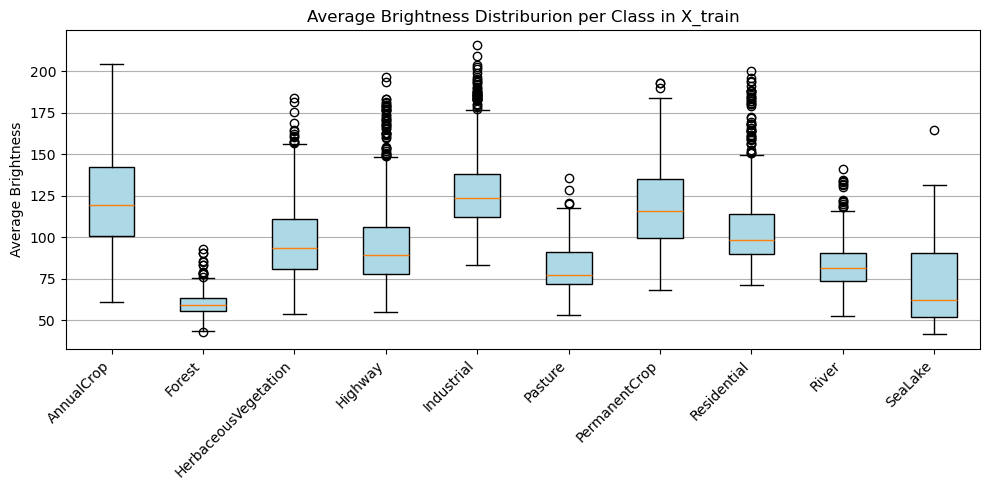

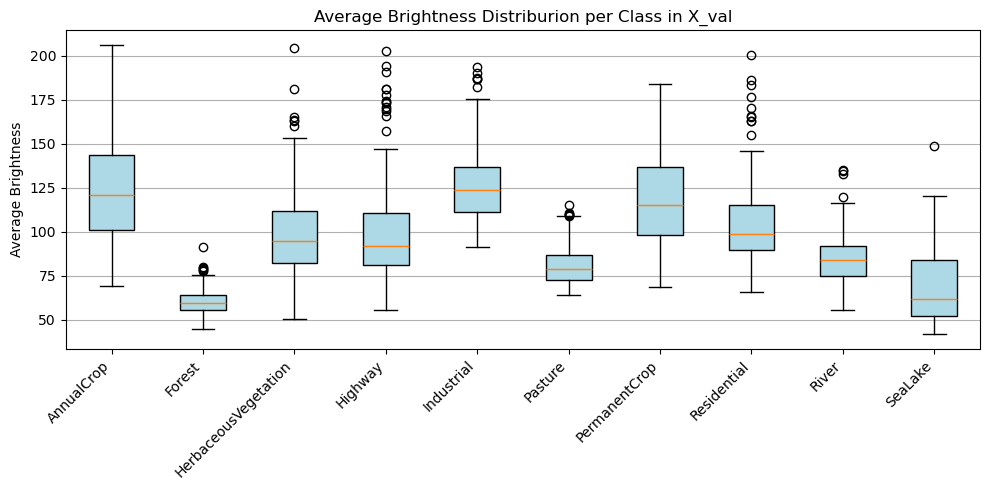

In [107]:
# your code goes here (average_brightness_per_class)
def average_brightness_per_class(df: pd.DataFrame, name: str) -> None:

    labels_all = []
    brightness_all = []
    for i in range(len(df)):
        img = Image.open(str(df.iloc[i].folder+"/"+df.iloc[i].file_name))
        label = df.iloc[i].file_name.split("_")[0]
        arr = np.array(img)
        labels_all.append(label)
        brightness_all.append(arr.mean())

    labels = sorted(set(labels_all))
    data = []
    for label in labels:
        data.append([brightness_all[i] for i in range(len(labels_all)) if labels_all[i] == label])

    plt.figure(figsize=(10,5))
    bp = plt.boxplot(data, labels=labels, patch_artist=True)
    for box in bp["boxes"]:
        box.set_facecolor("lightblue")
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Average Brightness Distriburion per Class in {name}")
    plt.ylabel("Average Brightness")
    plt.grid(axis="y")
    plt.gca().set_axisbelow(True)

    os.makedirs("assets/plots", exist_ok=True)
    plt.savefig(f"assets/plots/average_brightness_{name}.png")

    plt.tight_layout()
    plt.show()

average_brightness_per_class(X_train, "X_train")
average_brightness_per_class(X_val, "X_val")

## CNN Implementation and Training

### Dataset class

In [ ]:
# your code goes here

### Data Loaders

In [ ]:
# your code goes here

### Model Architecture

In [ ]:
# your code goes here

### Training Loop

In [ ]:
# your code goes here

## Model Evaluation

In [ ]:
# your code goes here (plot_training_curves)

In [ ]:
# your code goes here (plot_confusion_matrix)

In [ ]:
# your code goes here (plot_misclassified_samples)

### Test Set

In [ ]:
# your code goes here (preprocess_test_data)

In [ ]:
# your code goes here (create dataset and dataloader)

In [ ]:
# your code goes here (evaluate model on test set)

In [ ]:
# your code goes here (create submission csv file for challenge server)